<a href="https://www.kaggle.com/code/gamzegezgin/suspicious-activities-graduation-project-vbase?scriptVersionId=314091418" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# ****BÖLÜM 0 — IMPORT & SABİT PARAMETRELER****

In [32]:
# ╔══════════════════════════════════════════════════════════════╗
# ║         BÖLÜM 0 — IMPORT & SABİT PARAMETRELER            ║
# ║  Bu hücre tüm deneylerin ortak tabanıdır.                ║
# ║  Burası değişmeden kalır — her deney buraya dayanır.     ║
# ╚══════════════════════════════════════════════════════════════╝

import os
import re
import cv2
import time
import random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)
from tensorflow.keras.layers import (
    TimeDistributed, Conv2D, Flatten, LSTM, GRU,
    Bidirectional, Dense, Dropout, GlobalAveragePooling2D
)
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications import VGG16, MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ── Tekrarlanabilirlik İçin Seed ──────────────────────────────
# Aynı kodu çalıştıran herkesin aynı sonucu alması için
# numpy, python random ve tensorflow seed'leri aynı anda set ediyoruz.
SEED = 3
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

# ── Sınıflar ─────────────────────────────────────────────────
CLASSES = ["Fighting", "Vandalism", "NormalVideos"]
NUM_CLASSES = len(CLASSES)

# ── Görüntü & Sequence Parametreleri ─────────────────────────
# SEQ_LEN = 30: Her videodan eşit aralıklarla seçilen kare sayısı.
# 30 kare, hareketin akışını yakalamak için yeterli; daha fazlası
# RAM'i gereksiz yere doldurur, daha azı temporal ilişkiyi kaçırır.
# IMG_HEIGHT / IMG_WIDTH = 64: VGG16 ve MobileNetV2 her ikisi de
# bu boyutu kaldırır. 128 daha iyi olurdu ama Kaggle RAM'ine sığmaz.
IMG_HEIGHT  = 64
IMG_WIDTH   = 64
SEQ_LEN     = 30

# ── Eğitim Parametreleri ──────────────────────────────────────
# Tüm deneylerde aynı değerler kullanılır.
# Farklı bir değer denenirse burası DEĞİL, ilgili deney hücresi değişir.
BATCH_SIZE  = 4
EPOCHS      = 30
PATIENCE    = 10       # EarlyStopping: bu kadar epoch iyileşme olmazsa dur
TEST_SIZE   = 0.25     # %25 test, %75 train
FPS_TEST_N  = 10       # FPS ölçümünde kaç video kullanılacak

# ── Dataset Yolları ───────────────────────────────────────────
# Deney 1 ve 2 farklı dataset kullanacak, her ikisi de burada tanımlı.
DATASET_UCF = "/kaggle/input/datasets/odins0n/ucf-crime-dataset/Train"

# Deney 2 için ek datasetler buraya eklenecek (henüz boş)
DATASET_GENISLETILMIS = None  # Deney 2'ye gelindiğinde doldurulacak

# ── Çıktı Klasörü ─────────────────────────────────────────────
OUTPUT_DIR = "/kaggle/working"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("=" * 50)
print(f"  Sınıflar     : {CLASSES}")
print(f"  Görüntü boyutu: {IMG_HEIGHT}x{IMG_WIDTH}")
print(f"  Sequence uzunluğu: {SEQ_LEN} kare")
print(f"  Batch size   : {BATCH_SIZE}")
print(f"  Max epoch    : {EPOCHS}")
print(f"  EarlyStopping: patience={PATIENCE}")
print(f"  Test oranı   : {TEST_SIZE}")
print("=" * 50)

  Sınıflar     : ['Fighting', 'Vandalism', 'NormalVideos']
  Görüntü boyutu: 64x64
  Sequence uzunluğu: 30 kare
  Batch size   : 4
  Max epoch    : 30
  EarlyStopping: patience=10
  Test oranı   : 0.25


# ****BÖLÜM 1 — VERİ YÜKLEME & ÖN İŞLEME****

In [33]:
# ╔══════════════════════════════════════════════════════════════╗
# ║         BÖLÜM 1 — VERİ YÜKLEME & ÖN İŞLEME                ║
# ║  Deney 1.1 ve 1.2 için ortak pipeline.                     ║
# ║  Augmentation sadece train setine uygulanır.               ║
# ╚══════════════════════════════════════════════════════════════╝

# ── 1.1 Veri Setini Keşfet ────────────────────────────────────
# Kaç video var, kaç frame var — önce bakalım, sonra yükleyelim.

print("=" * 50)
print("VERİ SETİ ANALİZİ")
print("=" * 50)

for cls in CLASSES:
    path = os.path.join(DATASET_UCF, cls)
    files = sorted(os.listdir(path))

    videos = set()
    for f in files:
        match = re.match(r'(.+)_(\d+)\.png$', f)
        if match:
            videos.add(match.group(1))

    print(f"{cls}:")
    print(f"  Toplam video : {len(videos)}")
    print(f"  Toplam frame : {len(files)}")
print("=" * 50)

VERİ SETİ ANALİZİ
Fighting:
  Toplam video : 45
  Toplam frame : 24684
Vandalism:
  Toplam video : 45
  Toplam frame : 13626
NormalVideos:
  Toplam video : 800
  Toplam frame : 947768


In [34]:
# ── 1.2 Video Gruplarını Oluştur ──────────────────────────────
# Aynı videoya ait frame'leri bir arada tutuyoruz.
# Neden? Train/test split video bazında yapılacak.
# Frame bazında split yapılsaydı aynı videonun kareleri
# hem train'e hem test'e düşerdi → data leakage.

def get_video_groups(class_path, max_videos=30):
    files = sorted(os.listdir(class_path))
    groups = {}
    for f in files:
        match = re.match(r'(.+)_(\d+)\.png$', f)
        if match:
            video_name = match.group(1)
            frame_no   = int(match.group(2))
            if video_name not in groups:
                groups[video_name] = []
            groups[video_name].append((frame_no, f))
    for v in groups:
        groups[v].sort(key=lambda x: x[0])
    return dict(list(groups.items())[:max_videos])

In [35]:
# ── 1.3 Sequence Oluştur ──────────────────────────────────────
# Her videodan tam olarak SEQ_LEN=30 kare seçiyoruz.
# Neden 30? Az seçersen hareket akışını kaçırırsın,
# çok seçersen RAM dolar ve eğitim yavaşlar.
# Strateji: videoyu eşit aralıklara böl, her aralıktan 1 kare al.
# Bu sayede kısa ve uzun videolar aynı boyuta normalize edilir.

def load_sequences(dataset_path, classes, max_videos=30):
    features = []
    labels   = []
    paths    = []

    for class_idx, class_name in enumerate(classes):
        print(f"Yükleniyor: {class_name}")
        class_path   = os.path.join(dataset_path, class_name)
        video_groups = get_video_groups(class_path, max_videos=max_videos)

        for video_name, frame_list in video_groups.items():
            total = len(frame_list)
            if total < SEQ_LEN:
                continue

            # Eşit aralıklı kare seçimi
            step     = max(total // SEQ_LEN, 1)
            selected = frame_list[::step][:SEQ_LEN]
            if len(selected) < SEQ_LEN:
                continue

            sequence = []
            for _, fname in selected:
                img_path = os.path.join(class_path, fname)
                img = cv2.imread(img_path)
                if img is None:
                    break
                img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
                img = img / 255.0   # Normalize: 0-255 → 0-1
                sequence.append(img)

            if len(sequence) == SEQ_LEN:
                features.append(sequence)
                labels.append(class_idx)
                paths.append(video_name)

        print(f"  {len([l for l in labels if l == class_idx])} video yüklendi")

    return np.array(features), np.array(labels), paths


features, labels, paths = load_sequences(DATASET_UCF, CLASSES, max_videos=45)

print(f"\nToplam shape : {features.shape}")
print(f"  → {features.shape[0]} video")
print(f"  → {features.shape[1]} kare/video")
print(f"  → {features.shape[2]}x{features.shape[3]} piksel")
print(f"  → {features.shape[4]} kanal (RGB)")

Yükleniyor: Fighting
  45 video yüklendi
Yükleniyor: Vandalism
  45 video yüklendi
Yükleniyor: NormalVideos
  44 video yüklendi

Toplam shape : (134, 30, 64, 64, 3)
  → 134 video
  → 30 kare/video
  → 64x64 piksel
  → 3 kanal (RGB)


In [36]:
# ── 1.4 Train / Test Ayrımı ───────────────────────────────────
# Split ÖNCE yapılıyor, augmentation SONRA.
# Neden? Test verisi gerçek dünyayı temsil etmeli.
# Augmente edilmiş test verisiyle ölçülen accuracy şişirilmiş olur.

one_hot_labels = to_categorical(labels, num_classes=NUM_CLASSES)

features_train, features_test, labels_train, labels_test = train_test_split(
    features, one_hot_labels,
    test_size=TEST_SIZE,
    shuffle=True,
    random_state=SEED
)

print(f"Train seti : {features_train.shape[0]} video")
print(f"Test seti  : {features_test.shape[0]} video")

Train seti : 100 video
Test seti  : 34 video


In [37]:
# ── 1.5 Augmentation — Sadece Train'e ────────────────────────
# Augmentation: modele aynı videoyu farklı açılardan gösteriyoruz.
# Bu sayede model "sadece bu açıdan kavga böyle görünür" değil,
# "kavga genel olarak böyle görünür" öğreniyor.
# Test setine augmentation UYGULANMAZ.

datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=(0.8, 1.2),
    shear_range=10,
    channel_shift_range=20,
    fill_mode='reflect'
)

augmented_sequences = []
for seq_idx, sequence in enumerate(features_train):
    aug_seq = []
    for frame_idx, frame in enumerate(sequence):
        frame_uint8 = (frame * 255).astype(np.uint8)
        np.random.seed(SEED + seq_idx * 100 + frame_idx)  # tekrarlanabilir
        aug_frame = datagen.random_transform(frame_uint8)
        aug_seq.append(aug_frame / 255.0)
    augmented_sequences.append(aug_seq)

# Orijinal + augmented → train seti 2 katına çıkıyor
features_train = np.concatenate([features_train, np.array(augmented_sequences)], axis=0)
labels_train   = np.concatenate([labels_train, labels_train], axis=0)

print(f"Train (augmentation sonrası) : {features_train.shape[0]} video")
print(f"Test (değişmedi)             : {features_test.shape[0]} video")

Train (augmentation sonrası) : 200 video
Test (değişmedi)             : 34 video


# ****BÖLÜM 2 — DENEY 1.1: VGG16 + LSTM****

In [38]:
# ╔══════════════════════════════════════════════════════════════╗
# ║         BÖLÜM 2 — DENEY 1.1: VGG16 + LSTM                ║
# ║  Baz model. Yüksek doğruluk, ağır mimari.                ║
# ║  Tek model — ensemble yok.                               ║
# ╚══════════════════════════════════════════════════════════════╝

# ── 2.1 Model Mimarisi ────────────────────────────────────────
# VGG16: Her kareyi ayrı ayrı işler, özellik çıkarır.
# Neden frozen? ImageNet'te milyonlarca görüntüyle öğrenilmiş
# ağırlıkları bozmak istemiyoruz. Sadece üstüne LSTM ekliyoruz.
# LSTM: 30 kare boyunca "ne değişti?" sorusunu yanıtlar.
# Yani VGG16 = göz, LSTM = hafıza.

def build_vgg16_lstm():
    vgg = VGG16(
        include_top=False,
        weights='imagenet',
        input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
    )
    vgg.trainable = False  # Frozen — ağırlıklar güncellenmez

    model = Sequential([
        TimeDistributed(vgg, input_shape=(SEQ_LEN, IMG_HEIGHT, IMG_WIDTH, 3)),
        TimeDistributed(GlobalAveragePooling2D()),  # Flatten yerine — daha az parametre
        LSTM(64, return_sequences=False),
        Dropout(0.3),
        Dense(NUM_CLASSES, activation='softmax')
    ])

    model.compile(
        loss='categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    return model


model_d11 = build_vgg16_lstm()
model_d11.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_4              │ (None, 30, 2, 2, 512)  │    14,714,688 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_5              │ (None, 30, 512)        │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │       147,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,862,595 (56.70 MB)

 Trainable params: 147,907 (577.76 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [39]:
# ── 2.2 Eğitim ────────────────────────────────────────────────
# EarlyStopping: val_loss izleniyor — validation kaybı
# PATIENCE epoch boyunca iyileşmezse eğitim durur.
# Neden val_loss? Train accuracy'yi izlemek overfitting'i kaçırır.
# ModelCheckpoint: En iyi validation anındaki ağırlıkları kaydeder.

callbacks_d11 = [
    EarlyStopping(
        monitor='val_loss',
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=f"{OUTPUT_DIR}/deney1_1_vgg16_lstm_best.keras",
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

print("Deney 1.1 eğitimi başlıyor — VGG16 + LSTM")
print("=" * 50)

start_train = time.time()

history_d11 = model_d11.fit(
    x=features_train,
    y=labels_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=TEST_SIZE,
    callbacks=callbacks_d11,
    shuffle=True,
    verbose=1
)

train_time_d11 = time.time() - start_train
print(f"\nEğitim süresi: {train_time_d11/60:.1f} dakika")

Deney 1.1 eğitimi başlıyor — VGG16 + LSTM
Epoch 1/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.3799 - loss: 1.1644
Epoch 1: val_loss improved from inf to 1.11721, saving model to /kaggle/working/deney1_1_vgg16_lstm_best.keras
38/38 ━━━━━━━━━━━━━━━━━━━━ 164s 4s/step - accuracy: 0.3811 - loss: 1.1625 - val_accuracy: 0.4400 - val_loss: 1.1172
Epoch 2/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5684 - loss: 0.9353
Epoch 2: val_loss improved from 1.11721 to 1.05494, saving model to /kaggle/working/deney1_1_vgg16_lstm_best.keras
38/38 ━━━━━━━━━━━━━━━━━━━━ 141s 4s/step - accuracy: 0.5682 - loss: 0.9346 - val_accuracy: 0.4600 - val_loss: 1.0549
Epoch 3/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6012 - loss: 0.8498
Epoch 3: val_loss improved from 1.05494 to 1.05069, saving model to /kaggle/working/deney1_1_vgg16_lstm_best.keras
38/38 ━━━━━━━━━━━━━━━━━━━━ 133s 4s/step - accuracy: 0.6002 - loss: 0.8510 - val_accuracy: 0.4800 - val_loss: 1.0507
Epoch 4/30
38/38 ━━━

In [40]:
# ── 2.3 Tahmin ────────────────────────────────────────────────

y_pred_d11     = model_d11.predict(features_test, verbose=1)
y_pred_cls_d11 = np.argmax(y_pred_d11, axis=1)
y_true         = np.argmax(labels_test, axis=1)

2/2 ━━━━━━━━━━━━━━━━━━━━ 32s 6s/step


In [41]:
# ── 2.4 Metrikler ─────────────────────────────────────────────

acc_d11  = accuracy_score(y_true, y_pred_cls_d11)
f1_d11   = f1_score(y_true, y_pred_cls_d11, average='weighted')
prec_d11 = precision_score(y_true, y_pred_cls_d11, average='weighted')
rec_d11  = recall_score(y_true, y_pred_cls_d11, average='weighted')

# Model boyutu
model_d11.save(f"{OUTPUT_DIR}/deney1_1_vgg16_lstm_final.keras")
size_d11 = os.path.getsize(f"{OUTPUT_DIR}/deney1_1_vgg16_lstm_final.keras") / (1024 * 1024)

# FPS — tek model, FPS_TEST_N video üzerinde
# 1 video = 1 tahmin. Süreyi video sayısına bölüyoruz.
start_fps = time.time()
for s in features_test[:FPS_TEST_N]:
    model_d11.predict(np.expand_dims(s, axis=0), verbose=0)
fps_d11 = FPS_TEST_N / (time.time() - start_fps)

print("=" * 50)
print("  DENEY 1.1 — VGG16 + LSTM / UCF-CRIME")
print("=" * 50)
print(f"  Accuracy  : {acc_d11:.4f}  ({acc_d11*100:.2f}%)")
print(f"  F1 Score  : {f1_d11:.4f}")
print(f"  Precision : {prec_d11:.4f}")
print(f"  Recall    : {rec_d11:.4f}")
print(f"  FPS       : {fps_d11:.2f}")
print(f"  Boyut     : {size_d11:.1f} MB")
print("=" * 50)

  DENEY 1.1 — VGG16 + LSTM / UCF-CRIME
  Accuracy  : 0.5000  (50.00%)
  F1 Score  : 0.4910
  Precision : 0.4912
  Recall    : 0.5000
  FPS       : 1.07
  Boyut     : 57.9 MB


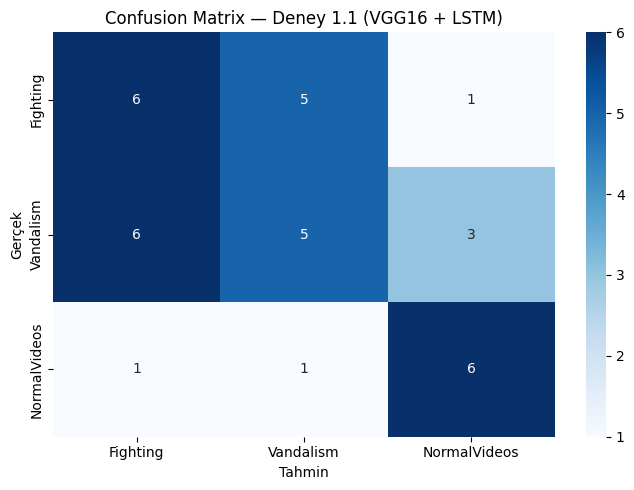

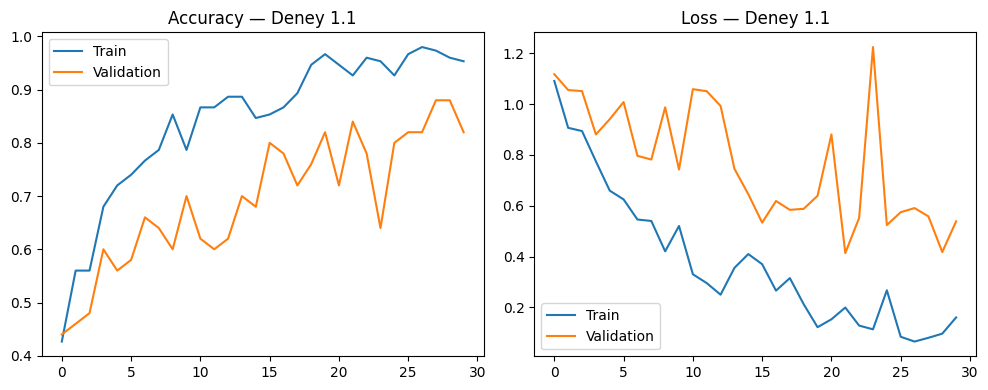

Görseller kaydedildi: /kaggle/working


In [42]:
# ── 2.5 Görseller ─────────────────────────────────────────────

# Confusion Matrix
cm_d11 = confusion_matrix(y_true, y_pred_cls_d11)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_d11, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Confusion Matrix — Deney 1.1 (VGG16 + LSTM)')
plt.ylabel('Gerçek')
plt.xlabel('Tahmin')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/cm_deney1_1.png', dpi=150)
plt.show()

# Eğitim Eğrisi
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history_d11.history['accuracy'], label='Train')
plt.plot(history_d11.history['val_accuracy'], label='Validation')
plt.title('Accuracy — Deney 1.1')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_d11.history['loss'], label='Train')
plt.plot(history_d11.history['val_loss'], label='Validation')
plt.title('Loss — Deney 1.1')
plt.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/egitim_egrisi_deney1_1.png', dpi=150)
plt.show()

print(f"Görseller kaydedildi: {OUTPUT_DIR}")

In [43]:
import json

# Deney 1.1 sonuçlarını diske kaydet
results_d11 = {
    'acc': float(acc_d11),
    'f1': float(f1_d11),
    'fps': float(fps_d11),
    'size': float(size_d11)
}
with open(f"{OUTPUT_DIR}/results_d11.json", "w") as f:
    json.dump(results_d11, f)
print("Deney 1.1 sonuçları kaydedildi.")

Deney 1.1 sonuçları kaydedildi.


# ****BÖLÜM 3 — Deney 1.2: MobileNetV2 + LSTM****

In [44]:
# ╔══════════════════════════════════════════════════════════════╗
# ║         BÖLÜM 3 — DENEY 1.2: MobileNetV2 + LSTM           ║
# ║  Hız odaklı model. VGG16 ile aynı veri, farklı backbone.  ║
# ║  Karşılaştırma: Accuracy vs FPS vs Model Boyutu            ║
# ╚══════════════════════════════════════════════════════════════╝

# ── 3.1 Model Mimarisi ────────────────────────────────────────
# MobileNetV2: VGG16'ya göre çok daha hafif ve hızlı.
# Depthwise separable convolution kullanır — aynı işi daha az
# parametreyle yapar. Mobil ve edge cihazlar için tasarlanmış.
# VGG16 = 138M parametre, MobileNetV2 = 3.4M parametre.
# Burada da frozen kullanıyoruz — ImageNet ağırlıkları korunuyor.

def build_mobilenet_lstm():
    mobilenet = MobileNetV2(
        include_top=False,
        weights='imagenet',
        input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
    )
    mobilenet.trainable = False  # Frozen

    model = Sequential([
        TimeDistributed(mobilenet, input_shape=(SEQ_LEN, IMG_HEIGHT, IMG_WIDTH, 3)),
        TimeDistributed(GlobalAveragePooling2D()),
        LSTM(64, return_sequences=False),
        Dropout(0.3),
        Dense(NUM_CLASSES, activation='softmax')
    ])

    model.compile(
        loss='categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    return model


model_d12 = build_mobilenet_lstm()
model_d12.summary()

/tmp/ipykernel_55/2700415445.py:15: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobilenet = MobileNetV2(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_6              │ (None, 30, 2, 2, 1280) │     2,257,984 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_7              │ (None, 30, 1280)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │       344,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,602,499 (9.93 MB)

 Trainable params: 344,515 (1.31 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [45]:
# ── 3.2 Eğitim ────────────────────────────────────────────────
# Deney 1.1 ile birebir aynı eğitim koşulları.
# Tek fark: model mimarisi. Bu kontrollü deney mantığı.

callbacks_d12 = [
    EarlyStopping(
        monitor='val_loss',
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=f"{OUTPUT_DIR}/deney1_2_mobilenet_lstm_best.keras",
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

print("Deney 1.2 eğitimi başlıyor — MobileNetV2 + LSTM")
print("=" * 50)

start_train_d12 = time.time()

history_d12 = model_d12.fit(
    x=features_train,
    y=labels_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=TEST_SIZE,
    callbacks=callbacks_d12,
    shuffle=True,
    verbose=1
)

train_time_d12 = time.time() - start_train_d12
print(f"\nEğitim süresi: {train_time_d12/60:.1f} dakika")

Deney 1.2 eğitimi başlıyor — MobileNetV2 + LSTM
Epoch 1/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - accuracy: 0.3073 - loss: 1.1629
Epoch 1: val_loss improved from inf to 0.96804, saving model to /kaggle/working/deney1_2_mobilenet_lstm_best.keras
38/38 ━━━━━━━━━━━━━━━━━━━━ 185s 2s/step - accuracy: 0.3093 - loss: 1.1607 - val_accuracy: 0.4800 - val_loss: 0.9680
Epoch 2/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.8386 - loss: 0.5433
Epoch 2: val_loss improved from 0.96804 to 0.83970, saving model to /kaggle/working/deney1_2_mobilenet_lstm_best.keras
38/38 ━━━━━━━━━━━━━━━━━━━━ 12s 313ms/step - accuracy: 0.8376 - loss: 0.5439 - val_accuracy: 0.6400 - val_loss: 0.8397
Epoch 3/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.9389 - loss: 0.2505
Epoch 3: val_loss improved from 0.83970 to 0.64313, saving model to /kaggle/working/deney1_2_mobilenet_lstm_best.keras
38/38 ━━━━━━━━━━━━━━━━━━━━ 12s 310ms/step - accuracy: 0.9391 - loss: 0.2511 - val_accuracy: 0.7400 - val_lo

In [46]:
# ── 3.3 Tahmin ────────────────────────────────────────────────

y_pred_d12     = model_d12.predict(features_test, verbose=1)
y_pred_cls_d12 = np.argmax(y_pred_d12, axis=1)

2/2 ━━━━━━━━━━━━━━━━━━━━ 80s 39s/step


In [47]:
# ── 3.4 Metrikler
y_true = np.argmax(labels_test, axis=1)  # ← EN ÜSTE OLMALI

acc_d12  = accuracy_score(y_true, y_pred_cls_d12)
f1_d12   = f1_score(y_true, y_pred_cls_d12, average='weighted')
prec_d12 = precision_score(y_true, y_pred_cls_d12, average='weighted')
rec_d12  = recall_score(y_true, y_pred_cls_d12, average='weighted')

# Model boyutu
model_d12.save(f"{OUTPUT_DIR}/deney1_2_mobilenet_lstm_final.keras")
size_d12 = os.path.getsize(f"{OUTPUT_DIR}/deney1_2_mobilenet_lstm_final.keras") / (1024 * 1024)

# FPS
start_fps = time.time()
for s in features_test[:FPS_TEST_N]:
    model_d12.predict(np.expand_dims(s, axis=0), verbose=0)
fps_d12 = FPS_TEST_N / (time.time() - start_fps)

print("=" * 50)
print("  DENEY 1.2 — MobileNetV2 + LSTM / UCF-CRIME")
print("=" * 50)
print(f"  Accuracy  : {acc_d12:.4f}  ({acc_d12*100:.2f}%)")
print(f"  F1 Score  : {f1_d12:.4f}")
print(f"  Precision : {prec_d12:.4f}")
print(f"  Recall    : {rec_d12:.4f}")
print(f"  FPS       : {fps_d12:.2f}")
print(f"  Boyut     : {size_d12:.1f} MB")
print("=" * 50)

  DENEY 1.2 — MobileNetV2 + LSTM / UCF-CRIME
  Accuracy  : 0.4412  (44.12%)
  F1 Score  : 0.4318
  Precision : 0.4561
  Recall    : 0.4412
  FPS       : 5.49
  Boyut     : 13.1 MB


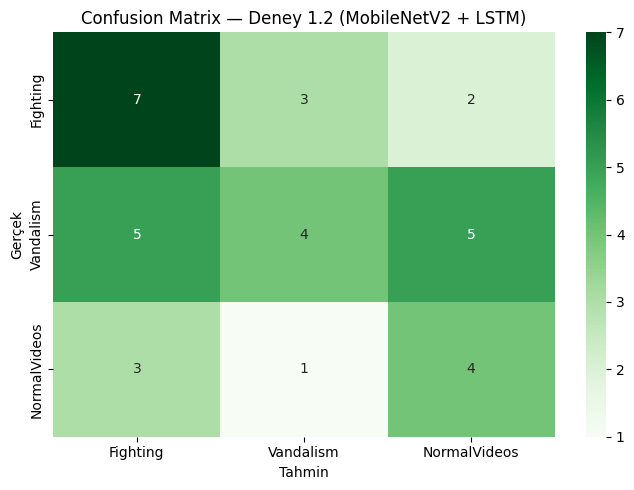

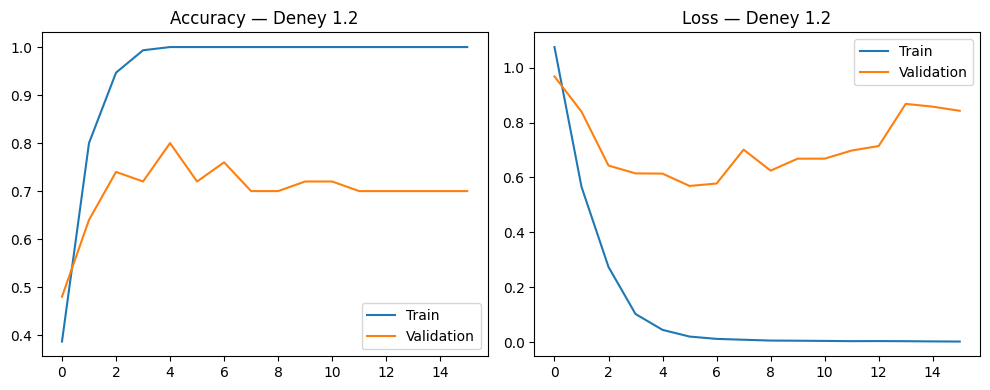

Görseller kaydedildi: /kaggle/working


In [48]:
# ── 3.5 Görseller ─────────────────────────────────────────────

# Confusion Matrix
cm_d12 = confusion_matrix(y_true, y_pred_cls_d12)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_d12, annot=True, fmt='d', cmap='Greens',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Confusion Matrix — Deney 1.2 (MobileNetV2 + LSTM)')
plt.ylabel('Gerçek')
plt.xlabel('Tahmin')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/cm_deney1_2.png', dpi=150)
plt.show()

# Eğitim Eğrisi
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history_d12.history['accuracy'], label='Train')
plt.plot(history_d12.history['val_accuracy'], label='Validation')
plt.title('Accuracy — Deney 1.2')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_d12.history['loss'], label='Train')
plt.plot(history_d12.history['val_loss'], label='Validation')
plt.title('Loss — Deney 1.2')
plt.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/egitim_egrisi_deney1_2.png', dpi=150)
plt.show()

print(f"Görseller kaydedildi: {OUTPUT_DIR}")

In [49]:
# ── 3.6 Deney 1 Karşılaştırma Özeti ──────────────────────────

y_true = np.argmax(labels_test, axis=1)

# Deney 1.1 metrikleri
y_pred_cls_d11 = np.argmax(model_d11.predict(features_test, verbose=0), axis=1)
acc_d11  = accuracy_score(y_true, y_pred_cls_d11)
f1_d11   = f1_score(y_true, y_pred_cls_d11, average='weighted')
size_d11 = os.path.getsize(f"{OUTPUT_DIR}/deney1_1_vgg16_lstm_final.keras") / (1024 * 1024)
start_fps = time.time()
for s in features_test[:FPS_TEST_N]:
    model_d11.predict(np.expand_dims(s, axis=0), verbose=0)
fps_d11 = FPS_TEST_N / (time.time() - start_fps)

# Deney 1.2 metrikleri
y_pred_cls_d12 = np.argmax(model_d12.predict(features_test, verbose=0), axis=1)
acc_d12  = accuracy_score(y_true, y_pred_cls_d12)
f1_d12   = f1_score(y_true, y_pred_cls_d12, average='weighted')
size_d12 = os.path.getsize(f"{OUTPUT_DIR}/deney1_2_mobilenet_lstm_final.keras") / (1024 * 1024)
start_fps = time.time()
for s in features_test[:FPS_TEST_N]:
    model_d12.predict(np.expand_dims(s, axis=0), verbose=0)
fps_d12 = FPS_TEST_N / (time.time() - start_fps)

# Sonuçları sakla
results = {}
results['d11'] = {'acc': acc_d11, 'f1': f1_d11, 'fps': fps_d11, 'size': size_d11}
results['d12'] = {'acc': acc_d12, 'f1': f1_d12, 'fps': fps_d12, 'size': size_d12}

# Karşılaştırma tablosu
print("=" * 55)
print("  DENEY 1 — VGG16 + LSTM  vs  MobileNetV2 + LSTM")
print("=" * 55)
print(f"{'Metrik':<15} {'Deney 1.1 (VGG16)':>18} {'Deney 1.2 (Mobile)':>18}")
print("-" * 55)
print(f"{'Accuracy (%)':<15} {acc_d11*100:>18.2f} {acc_d12*100:>18.2f}")
print(f"{'F1 Score':<15} {f1_d11:>18.4f} {f1_d12:>18.4f}")
print(f"{'FPS':<15} {fps_d11:>18.2f} {fps_d12:>18.2f}")
print(f"{'Boyut (MB)':<15} {size_d11:>18.1f} {size_d12:>18.1f}")
print("=" * 55)

  DENEY 1 — VGG16 + LSTM  vs  MobileNetV2 + LSTM
Metrik           Deney 1.1 (VGG16) Deney 1.2 (Mobile)
-------------------------------------------------------
Accuracy (%)                 50.00              44.12
F1 Score                    0.4910             0.4318
FPS                           1.07               5.70
Boyut (MB)                    57.9               13.1
